Loaded 10 datasets from Full_Dataset_Revised.csv
Columns: ['Dataset', 'DoS', 'DDoS', 'Probe', 'U2R', 'R2L', 'Source', 'Regular_Traffic', 'Basic_Feature', 'Traffic_Feature', 'Content_Feature', 'Release_Year', 'Meta_Data', 'Data_Format', 'Predefine_Split', 'Benign_Data', 'Balanced', 'Labelled', 'Availability']

Computing scores for all datasets...

DATASET EVALUATION SCORES (Aligned with Revised Section 5)
                 Attack Coverage  Provenance Source  Feature Diversity  Documentation & Metadata  Evaluation Readiness  Availability  Overall (Mean)
Dataset                                                                                                                                             
LITNET-2020                 1.25                5.0               3.33                      3.33                  3.75           5.0            3.61
CIC Modbus 2023             2.50                3.0               5.00                      5.00                  3.75           5.0            4

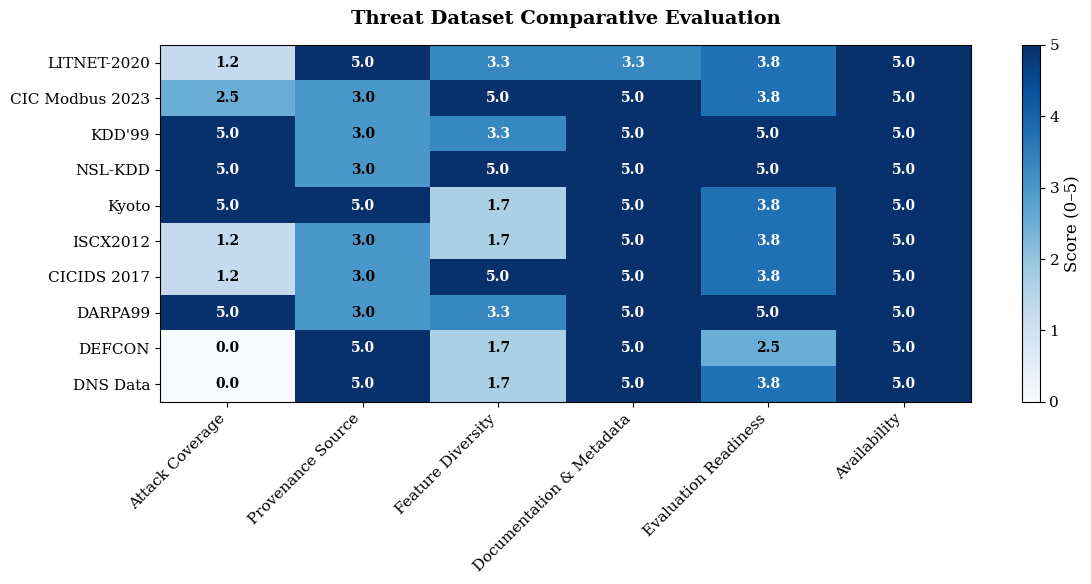

Generating Visualization 2: Multi-line Category Scores...
✓ Saved: multiline_categories_revised.png


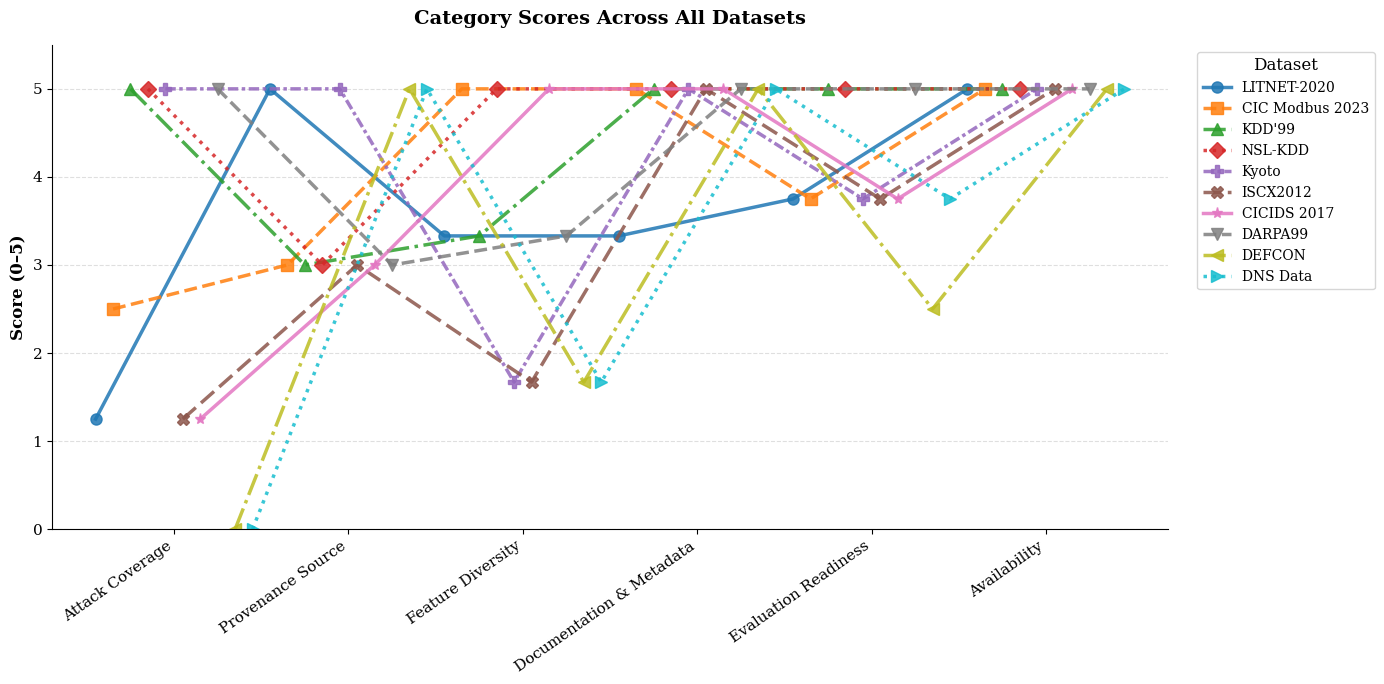

Generating Visualization 3: Radar Chart (Top-5)...
✓ Saved: radar_top5_revised.png


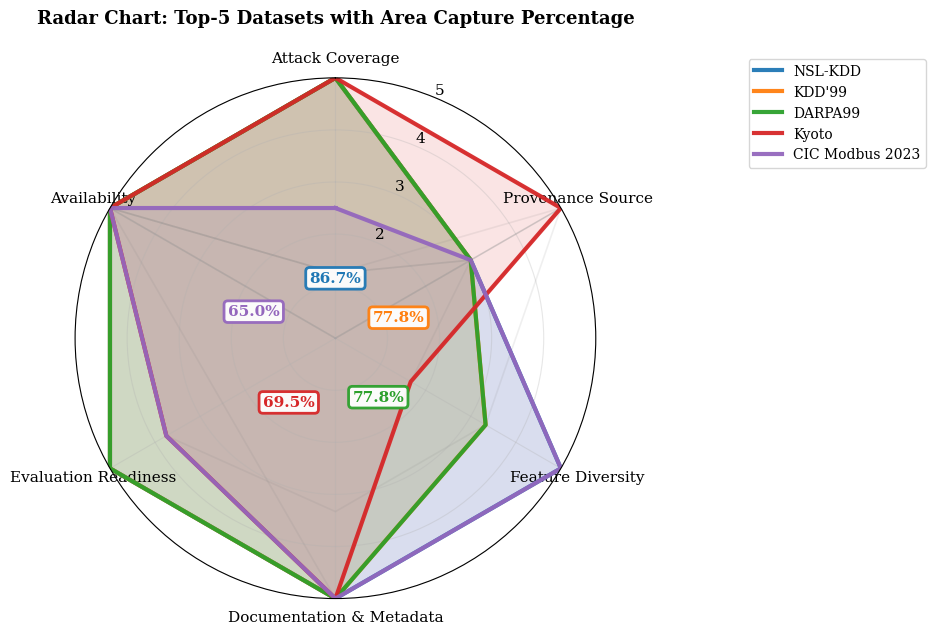

Generating Visualization 4: Overall Performance Bar Chart...
✓ Saved: overall_ranking_revised.png


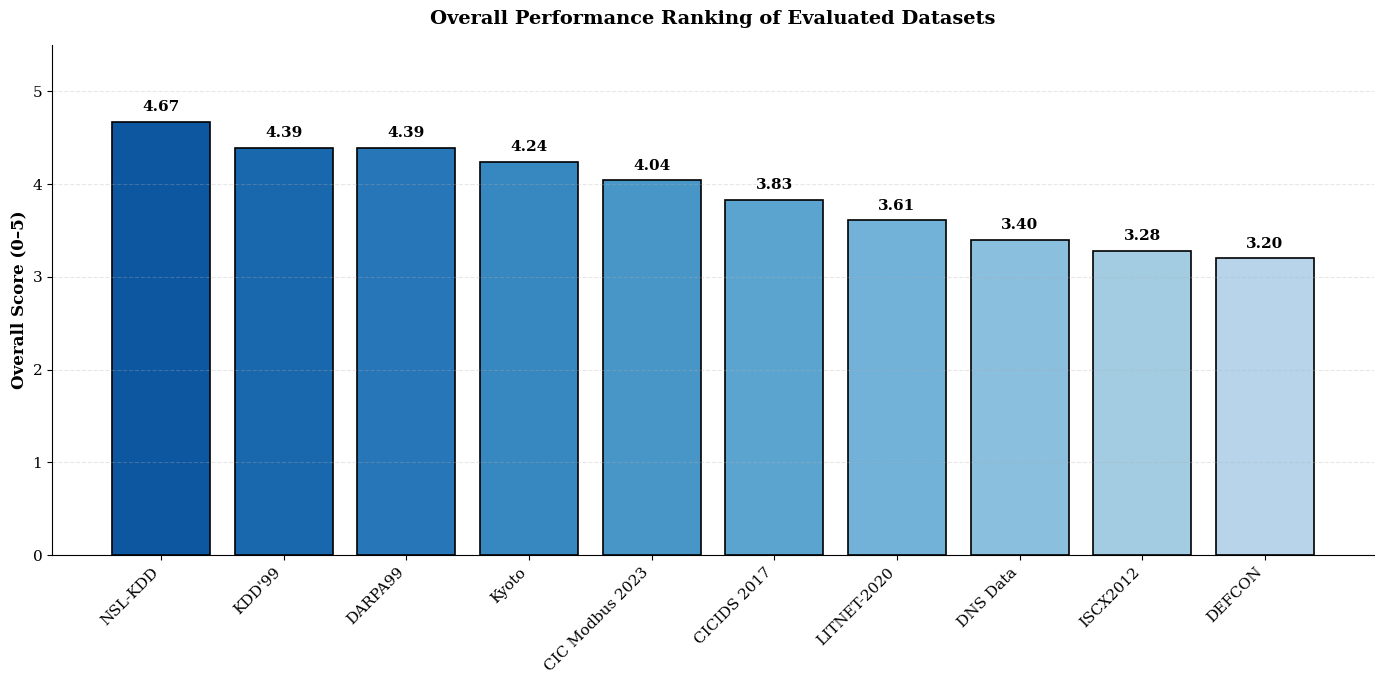


SUMMARY STATISTICS

Total datasets evaluated: 10

Overall Score Statistics:
  Mean:   3.91
  Median: 3.94
  Std:    0.52
  Min:    3.20 (DEFCON)
  Max:    4.67 (NSL-KDD)

EVALUATION COMPLETE

Generated files:
  1. dataset_scores_revised.csv
  2. heatmap_revised.png
  3. multiline_categories_revised.png
  4. radar_top5_revised.png
  5. overall_ranking_revised.png




In [1]:
"""
Dataset Evaluation Framework 
=============================================================

This script implements the 6-category evaluation:
1. Attack Coverage (S_attack)
2. Provenance Source (S_source)
3. Feature Diversity (S_feat)
4. Documentation & Metadata (S_meta)
5. Evaluation Readiness (S_eval)
6. Availability (S_avail)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif", "serif"],
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# ---------- 1) Load dataset descriptor ----------
src = Path("Full_Dataset_Revised.csv")
df = pd.read_csv(src)

# Clean dataset names
df["Dataset"] = df["Dataset"].astype(str).str.strip()
df = df[df["Dataset"].notna() & (df["Dataset"] != "") & (df["Dataset"].str.lower() != "nan")].copy()

print(f"Loaded {len(df)} datasets from {src}")
print(f"Columns: {list(df.columns)}\n")

# ---------- 2) Helper function ----------
def as_bool(x):
    """Convert various representations to boolean."""
    if pd.isna(x):
        return False
    if isinstance(x, (int, float, np.integer, np.floating)):
        return bool(int(x))
    if isinstance(x, str):
        t = x.strip().lower()
        if t in {"true", "yes", "y", "1"}:
            return True
        if t in {"false", "no", "n", "0", ""}:
            return False
    return bool(x)


# ---------- 3) REVISED SCORING FUNCTIONS ----------

def score_attack_coverage(r):
    """
    Category 1: Attack Coverage
    Formula: S_attack(d) = (5/|A|) × Σ 𝟙{a present in d}
    
    Note: Framework uses 4 baseline attacks (DoS/DDoS combined, Probe, U2R, R2L)
    But dataset has DoS and DDoS as separate columns.
    
    We'll score based on 4 baseline categories as per Section 5.3:
    - DoS/DDoS (either DoS OR DDoS counts)
    - Probe
    - U2R
    - R2L
    """
    ATTACK_BASELINE = {
        "DoS/DDoS": ["DoS", "DDoS"],  # Either counts
        "Probe": ["Probe"],
        "U2R": ["U2R"],
        "R2L": ["R2L"]
    }
    
    present_count = 0
    for attack_category, column_names in ATTACK_BASELINE.items():
        # Check if ANY of the columns for this category are TRUE
        if any(as_bool(r.get(col, False)) for col in column_names):
            present_count += 1
    
    total_categories = len(ATTACK_BASELINE)  # 4
    return round(5 * present_count / total_categories, 2)


def score_provenance(r):
    """
    Category 2: Provenance Source
    Formula: S_source(d) = base(Source)
        
    Real-world = 5
    Emulated = 3
    Synthetic = 1
    """
    src_val = str(r.get("Source", "")).strip().lower()
    
    base_scores = {
        "real": 5,
        "emulated": 3,
        "synthetic": 1
    }
    
    return float(base_scores.get(src_val, 0))


def score_feature_diversity(r):
    """
    Category 3: Feature Diversity
    Formula: S_feat(d) = (5/|F|) × Σ 𝟙{f present in d}
    
    F = {Basic_Feature, Traffic_Feature, Content_Feature}
    """
    FEATURE_COLS = ["Basic_Feature", "Traffic_Feature", "Content_Feature"]
    
    present = sum(as_bool(r.get(c, False)) for c in FEATURE_COLS)
    total = len(FEATURE_COLS)  # 3
    
    return round(5 * present / total, 2)


def score_documentation_metadata(r):
    """
    Category 4: Documentation & Metadata
    Formula: S_meta(d) = (5/3) × n_M
    
    Three criteria:
    1. Release year documented
    2. Metadata available
    3. Data format specified
    """
    # Check 1: Release year
    ry = r.get("Release_Year", "")
    ry_ok = 0
    if not pd.isna(ry):
        s = str(ry).strip()
        if s not in {"", "0", "0.0", "nan", "none"}:
            ry_ok = 1
    
    # Check 2: Metadata
    meta_ok = int(as_bool(r.get("Meta_Data", False)))
    
    # Check 3: Data format
    df_val = str(r.get("Data_Format", "")).strip().lower()
    format_ok = 0 if df_val in {"", "nan", "none"} else 1
    
    n_M = ry_ok + meta_ok + format_ok
    return round(5 * n_M / 3, 2)


def score_evaluation_readiness(r):
    """
    Category 5: Evaluation Readiness
    Formula: S_eval(d) = (5/4) × n_E
    
    Now 4 criteria:
    1. Labels present
    2. Predefined split available
    3. Benign data confirmed (MOVED from S_source)
    4. Class balance documented/inferrable
    
    Conservative rule for balance:
    Balance_confirmed = Balanced OR (Benign_Data AND Attack_Data)
    """
    # Criterion 1: Labels
    labels_ok = int(as_bool(r.get("Labelled", False)))
    
    # Criterion 2: Predefined split
    split_ok = int(as_bool(r.get("Predefine_Split", False)))
    
    # Criterion 3: Benign data (NEW - moved from provenance)
    benign_ok = int(as_bool(r.get("Benign_Data", False)))
    
    # Criterion 4: Balance (conservative inference)
    balanced_explicit = as_bool(r.get("Balanced", False))
    benign_present = as_bool(r.get("Benign_Data", False))
    
    # Check if ANY attack is present
    attack_cols = ["DoS", "DDoS", "Probe", "U2R", "R2L"]
    attack_present = any(as_bool(r.get(col, False)) for col in attack_cols)
    
    # Conservative rule: balanced if explicitly stated OR (benign AND attack both present)
    balance_ok = int(balanced_explicit or (benign_present and attack_present))
    
    n_E = labels_ok + split_ok + benign_ok + balance_ok
    return round(5 * n_E / 4, 2)


def score_availability(r):
    """
    Category 6: Availability
    Formula: S_avail(d) ∈ {1, 3, 5}
    
    Public = 5
    On request = 3
    Restricted/unclear = 1
    """
    avail = str(r.get("Availability", "")).strip().lower().replace(" ", "")
    
    availability_scores = {
        "public": 5,
        "open": 5,
        "opensource": 5,
        "onrequest": 3,
        "request": 3,
        "n/a": 1,
        "no": 1,
        "restricted": 1
    }
    
    return float(availability_scores.get(avail, 1))


# ---------- 4) Build scoring table ----------
print("Computing scores for all datasets...\n")

rows = []
for idx, r in df.iterrows():
    s1 = score_attack_coverage(r)
    s2 = score_provenance(r)
    s3 = score_feature_diversity(r)
    s4 = score_documentation_metadata(r)
    s5 = score_evaluation_readiness(r)
    s6 = score_availability(r)
    
    overall = round(np.mean([s1, s2, s3, s4, s5, s6]), 2)
    
    rows.append({
        "Dataset": r["Dataset"],
        "Attack Coverage": s1,
        "Provenance Source": s2,
        "Feature Diversity": s3,
        "Documentation & Metadata": s4,
        "Evaluation Readiness": s5,
        "Availability": s6,
        "Overall (Mean)": overall
    })

scores = pd.DataFrame(rows).set_index("Dataset")

# Print summary
print("=" * 80)
print("DATASET EVALUATION SCORES (Aligned with Revised Section 5)")
print("=" * 80)
print(scores.to_string())
print("\n")

# ---------- 5) Save results ----------
out_csv = Path("dataset_scores_revised.csv")
scores.to_csv(out_csv)
print(f"✓ Scores saved to: {out_csv}\n")

# ---------- 6) Generate visualizations ----------

# ========== VISUALIZATION 1: Heatmap ==========
print("Generating Visualization 1: Heatmap...")

fig, ax = plt.subplots(figsize=(12, 6))
M = scores.drop(columns=["Overall (Mean)"]).values

cmap = plt.cm.Blues
im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=0, vmax=5)

ax.set_xticks(np.arange(M.shape[1]))
ax.set_xticklabels(scores.drop(columns=["Overall (Mean)"]).columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(scores.index)))
ax.set_yticklabels(scores.index)

# Add text annotations with adaptive color
norm = plt.Normalize(vmin=0, vmax=5)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        value = float(M[i, j])
        bg_color = cmap(norm(value))
        brightness = (0.299 * bg_color[0] + 0.587 * bg_color[1] + 0.114 * bg_color[2])
        text_color = "white" if brightness < 0.5 else "black"
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", 
                color=text_color, fontsize=10, fontweight="bold")

ax.set_title("Threat Dataset Comparative Evaluation", 
             fontweight="bold", pad=15)
fig.colorbar(im, ax=ax, label="Score (0–5)")
plt.tight_layout()
plt.savefig("heatmap_revised.png", dpi=300, bbox_inches="tight")
print("✓ Saved: heatmap_revised.png")
plt.show()

# ========== VISUALIZATION 2: Multi-line Category Scores ==========
print("Generating Visualization 2: Multi-line Category Scores...")

category_scores = scores.drop(columns=["Overall (Mean)"])
categories = list(category_scores.columns)
x = np.arange(len(categories))

ds_names = list(category_scores.index)
n = len(ds_names)

# Larger x-jitter to separate overlapping lines
SHIFT_RANGE = 0.45
offsets = np.linspace(-SHIFT_RANGE, SHIFT_RANGE, n) if n > 1 else np.array([0.0])

markers = ['o', 's', '^', 'D', 'P', 'X', '*', 'v', '<', '>', 'p', 'h']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

fig, ax = plt.subplots(figsize=(14, 7))

for i, ds in enumerate(ds_names):
    y = category_scores.loc[ds].values.astype(float)
    x_shift = x + offsets[i]
    ax.plot(
        x_shift, y,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,
        markersize=8,
        alpha=0.85,
        label=ds
    )

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.set_xlim(x.min() - (SHIFT_RANGE + 0.25), x.max() + (SHIFT_RANGE + 0.25))
ax.set_ylim(0, 5.5)
ax.set_ylabel("Score (0–5)", fontweight="bold")
ax.set_title("Category Scores Across All Datasets", 
             fontweight="bold", pad=15)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig("multiline_categories_revised.png", dpi=300, bbox_inches="tight")
print("✓ Saved: multiline_categories_revised.png")
plt.show()

# ========== VISUALIZATION 3: Radar Chart (Top-5 with Area Capture %) ==========
print("Generating Visualization 3: Radar Chart (Top-5)...")

cats = [c for c in scores.columns if c != "Overall (Mean)"]
data = scores[cats].astype(float)

N = len(cats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close loop

def closed_list(vals):
    v = vals.values.astype(float).tolist()
    return v + v[:1]

# Calculate radar area capture percentage
dtheta = 2 * np.pi / N

def radar_area(vals_closed):
    r = np.array(vals_closed, dtype=float)
    return 0.5 * np.sum(r[:-1] * r[1:] * np.sin(dtheta))

max_area = radar_area([5.0] * (N + 1))

def area_capture_pct(vals_closed):
    return 100.0 * radar_area(vals_closed) / max_area if max_area > 0 else 0.0

# Select top-k datasets
k = min(5, len(scores))
topk = scores["Overall (Mean)"].sort_values(ascending=False).head(k).index.tolist()

highlight_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

fig = plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

ax.set_theta_offset(np.deg2rad(90))
ax.set_theta_direction(-1)

# Background: all datasets (faint grey)
for ds in data.index:
    vals = closed_list(data.loc[ds])
    ax.plot(angles, vals, linewidth=1.2, alpha=0.12, color="0.5")

# Highlight top-k
for i, ds in enumerate(topk):
    vals = closed_list(data.loc[ds])
    c = highlight_colors[i % len(highlight_colors)]
    ax.plot(angles, vals, linewidth=3.0, alpha=0.95, color=c, label=ds)
    ax.fill(angles, vals, alpha=0.12, color=c)

# Axes formatting
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=11)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_ylim(0, 5)
ax.grid(alpha=0.3)

ax.set_title("Radar Chart: Top-5 Datasets with Area Capture Percentage", 
             fontweight="bold", pad=20, fontsize=13)
ax.legend(bbox_to_anchor=(1.28, 1.05), loc="upper left", frameon=True)

# Area percentage labels (non-overlapping placement)
label_thetas = np.linspace(0, 2*np.pi, k, endpoint=False)
label_radii = np.linspace(1.15, 1.65, k)

for i, ds in enumerate(topk):
    vals = closed_list(data.loc[ds])
    pct = area_capture_pct(vals)
    c = highlight_colors[i % len(highlight_colors)]
    
    th = label_thetas[i]
    rr = label_radii[i]
    
    ax.text(
        th, rr,
        f"{pct:.1f}%",
        ha="center", va="center",
        fontsize=11, fontweight="bold",
        color=c,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", 
                  edgecolor=c, linewidth=2, alpha=0.95)
    )

plt.tight_layout()
plt.savefig("radar_top5_revised.png", dpi=300, bbox_inches="tight")
print("✓ Saved: radar_top5_revised.png")
plt.show()

# ========== VISUALIZATION 4: Overall Performance Bar Chart ==========
print("Generating Visualization 4: Overall Performance Bar Chart...")

overall_scores = scores["Overall (Mean)"].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))

# Color mapping: highest (top) = light blue, lowest (bottom) = dark blue
colors = plt.cm.Blues(np.linspace(0.85, 0.30, len(overall_scores)))

bars = ax.bar(overall_scores.index, overall_scores.values, color=colors, 
              edgecolor='black', linewidth=1.2)

ax.set_title("Overall Performance Ranking of Evaluated Datasets", 
             fontweight="bold", pad=15, fontsize=14)
ax.set_ylabel("Overall Score (0–5)", fontweight="bold", fontsize=12)
ax.set_ylim(0, 5.5)

plt.xticks(rotation=45, ha="right")

# Add value labels on bars
for i, (bar, v) in enumerate(zip(bars, overall_scores.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.08,
            f"{v:.2f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("overall_ranking_revised.png", dpi=300, bbox_inches="tight")
print("✓ Saved: overall_ranking_revised.png")
plt.show()

# ========== Summary Statistics ==========
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(f"\nTotal datasets evaluated: {len(scores)}")
print(f"\nOverall Score Statistics:")
print(f"  Mean:   {scores['Overall (Mean)'].mean():.2f}")
print(f"  Median: {scores['Overall (Mean)'].median():.2f}")
print(f"  Std:    {scores['Overall (Mean)'].std():.2f}")
print(f"  Min:    {scores['Overall (Mean)'].min():.2f} ({scores['Overall (Mean)'].idxmin()})")
print(f"  Max:    {scores['Overall (Mean)'].max():.2f} ({scores['Overall (Mean)'].idxmax()})")

print("\n" + "=" * 80)
print("EVALUATION COMPLETE")
print("=" * 80)
print("\nGenerated files:")
print("  1. dataset_scores_revised.csv")
print("  2. heatmap_revised.png")
print("  3. multiline_categories_revised.png")
print("  4. radar_top5_revised.png")
print("  5. overall_ranking_revised.png")
print("\n")